Para analizar el archivo datos-covid-por-region.csv, Este script realiza una limpieza de datos, un análisis exploratorio descriptivo y genera visualizaciones interactivas y estáticas para observar la evolución de la pandemia en Chile.

In [4]:
library(datos)

In [5]:
# -------------------------------------------------------------------------
# Script: Análisis de Evolución COVID-19 por Región en Chile
# -------------------------------------------------------------------------

# 1. Carga de librerías
if (!require("tidyverse")) install.packages("tidyverse")
if (!require("lubridate")) install.packages("lubridate")
if (!require("skimr")) install.packages("skimr")
if (!require("scales")) install.packages("scales")

library(tidyverse)
library(lubridate)
library(skimr)
library(scales)

# 2. Carga del dataset
# Se utiliza read_csv para obtener un tibble y mejor manejo de tipos
covid_data <- read_csv("../../data/datos-covid-por-region.csv")

Rows: 4165 Columns: 3
── Column specification ─────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): Region
dbl  (1): Total
date (1): Fecha

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [6]:
# 3. Limpieza y Preparación de Datos
cat("--- Limpieza y Preparación ---\n")

covid_cleaned <- covid_data %>%
  # Asegurar que la fecha sea de tipo Date
  mutate(Fecha = as.Date(Fecha)) %>%
  # Filtrar valores nulos si existieran
  drop_na(Total) %>%
  # Ordenar cronológicamente
  arrange(Fecha)

# Separar el agregado nacional ("Total") de las regiones para análisis comparativo
df_regiones <- covid_cleaned %>% filter(Region != "Total")
df_nacional <- covid_cleaned %>% filter(Region == "Total")

# 4. EDA (Análisis Exploratorio de Datos)
cat("\n--- Resumen General del Dataset ---\n")
glimpse(covid_cleaned)

cat("\n--- Estadísticas Descriptivas ---\n")
skim(df_regiones)

--- Limpieza y Preparación ---

--- Resumen General del Dataset ---
Rows: 4,165
Columns: 3
$ Region <chr> "Arica y Parinacota", "Tarapacá", "Antofagasta", "Atacama", "Coquimbo", "Valpara…
$ Fecha  <date> 2020-03-03, 2020-03-03, 2020-03-03, 2020-03-03, 2020-03-03, 2020-03-03, 2020-03…
$ Total  <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0,…

--- Estadísticas Descriptivas ---


── Data Summary ────────────────────────
                           Values     
Name                       df_regiones
Number of rows             3920       
Number of columns          3          
_______________________               
Column type frequency:                
  character                1          
  Date                     1          
  numeric                  1          
________________________              
Group variables            None       

── Variable type: character ─────────────────────────────────────────────────────────────────────
  skim_variable n_missing complete_rate min max empty n_unique whitespace
1 Region                0             1   5  18     0       16          0

── Variable type: Date ──────────────────────────────────────────────────────────────────────────
  skim_variable n_missing complete_rate min        max        median     n_unique
1 Fecha                 0             1 2020-03-03 2020-11-02 2020-07-03      245

── Variable type: n

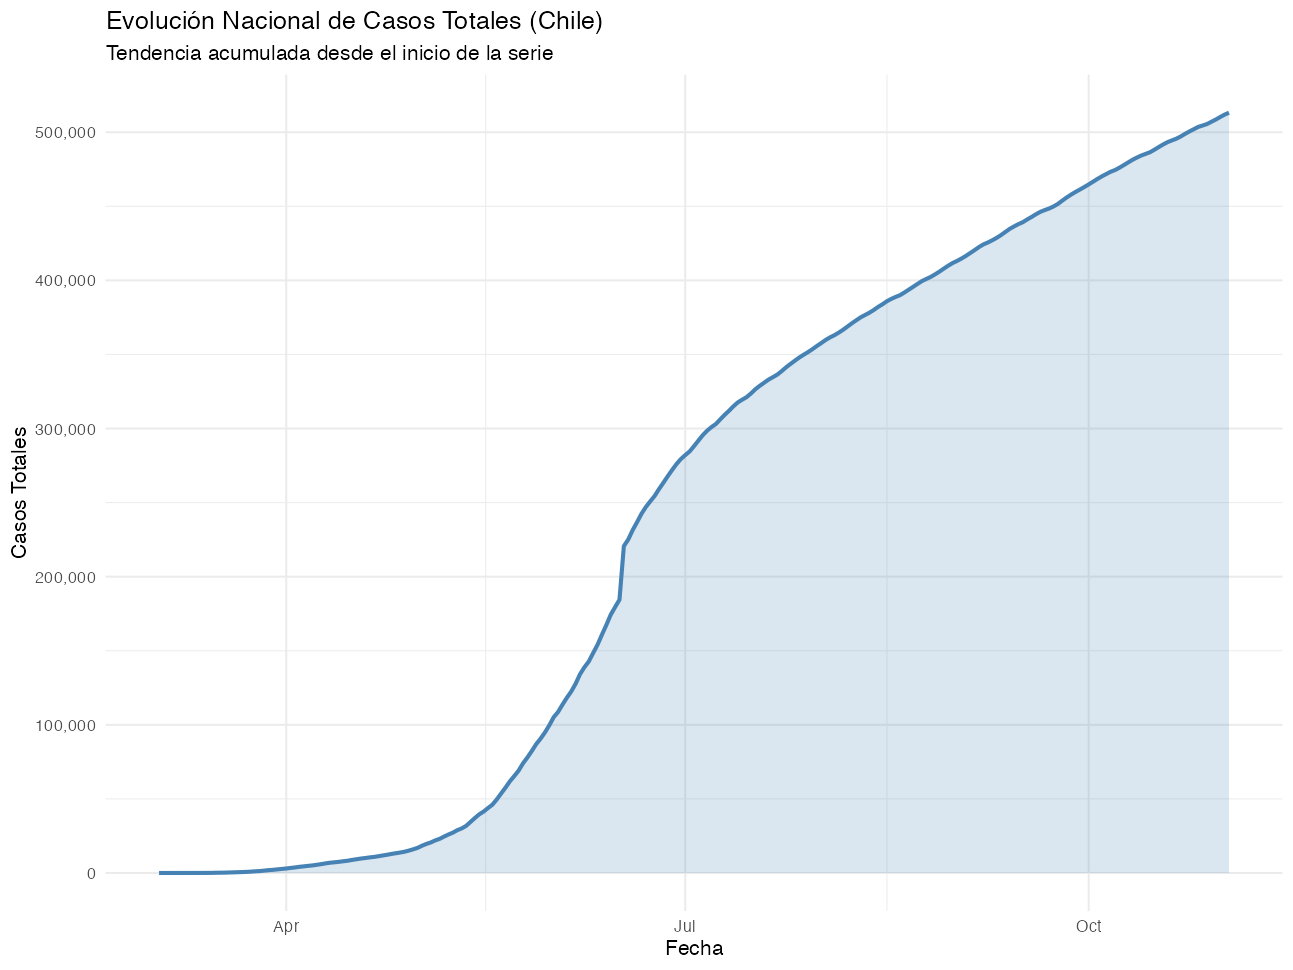

In [7]:
# 5. Visualización 1: Evolución Nacional (Total país)
ggplot(df_nacional, aes(x = Fecha, y = Total)) +
  geom_line(color = "steelblue", size = 1) +
  geom_area(fill = "steelblue", alpha = 0.2) +
  scale_y_continuous(labels = comma) +
  labs(title = "Evolución Nacional de Casos Totales (Chile)",
       subtitle = "Tendencia acumulada desde el inicio de la serie",
       x = "Fecha",
       y = "Casos Totales") +
  theme_minimal()

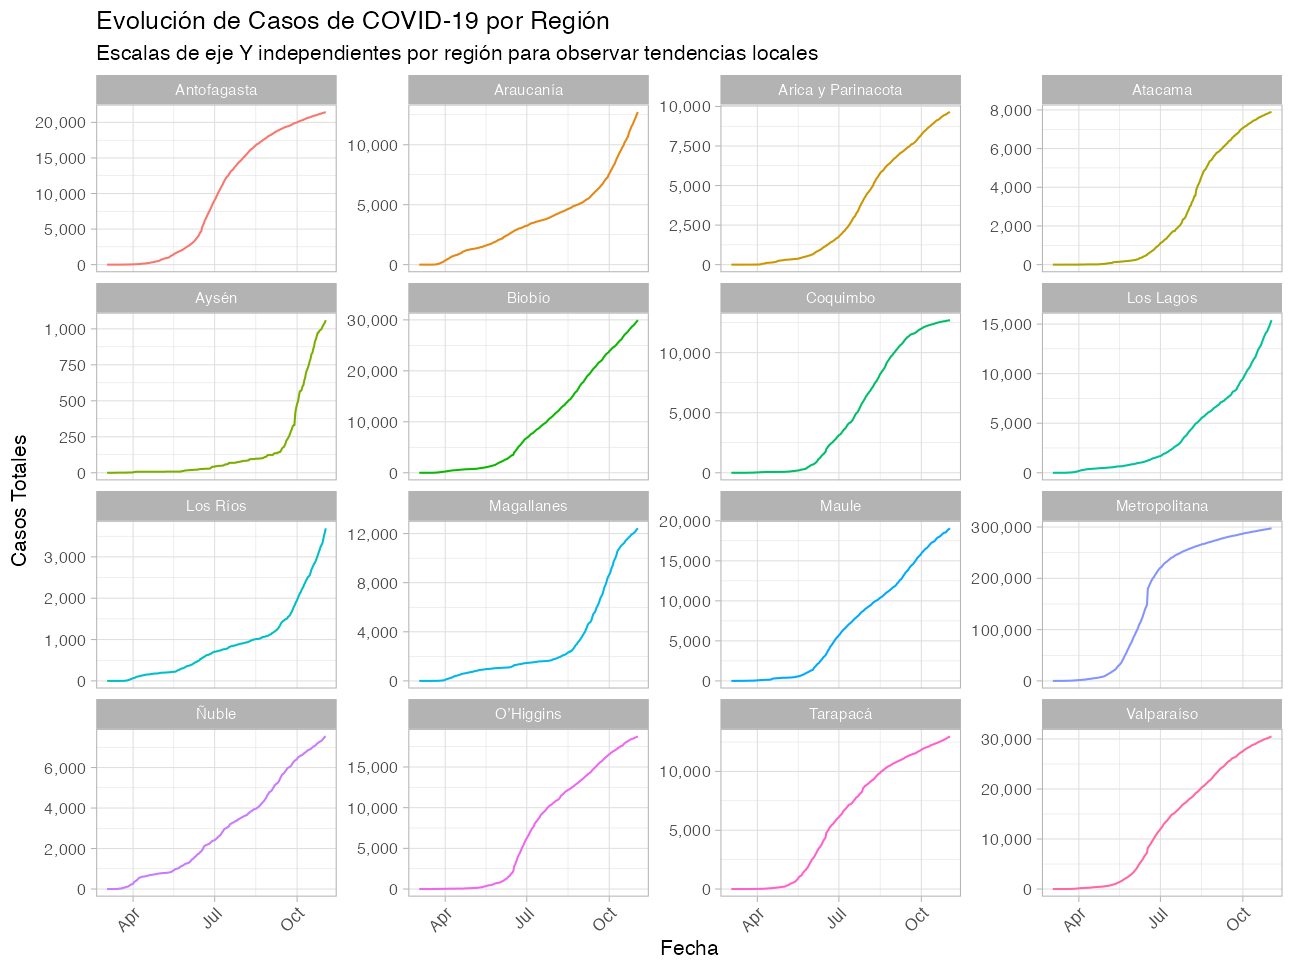

In [8]:
# 6. Visualización 2: Evolución Comparativa por Región
# Usamos facet_wrap para ver cada región individualmente
ggplot(df_regiones, aes(x = Fecha, y = Total, color = Region)) +
  geom_line(show.legend = FALSE) +
  facet_wrap(~Region, scales = "free_y") +
  scale_y_continuous(labels = comma) +
  labs(title = "Evolución de Casos de COVID-19 por Región",
       subtitle = "Escalas de eje Y independientes por región para observar tendencias locales",
       x = "Fecha",
       y = "Casos Totales") +
  theme_light() +
  theme(strip.text = element_text(size = 8),
        axis.text.x = element_text(angle = 45, hjust = 1))

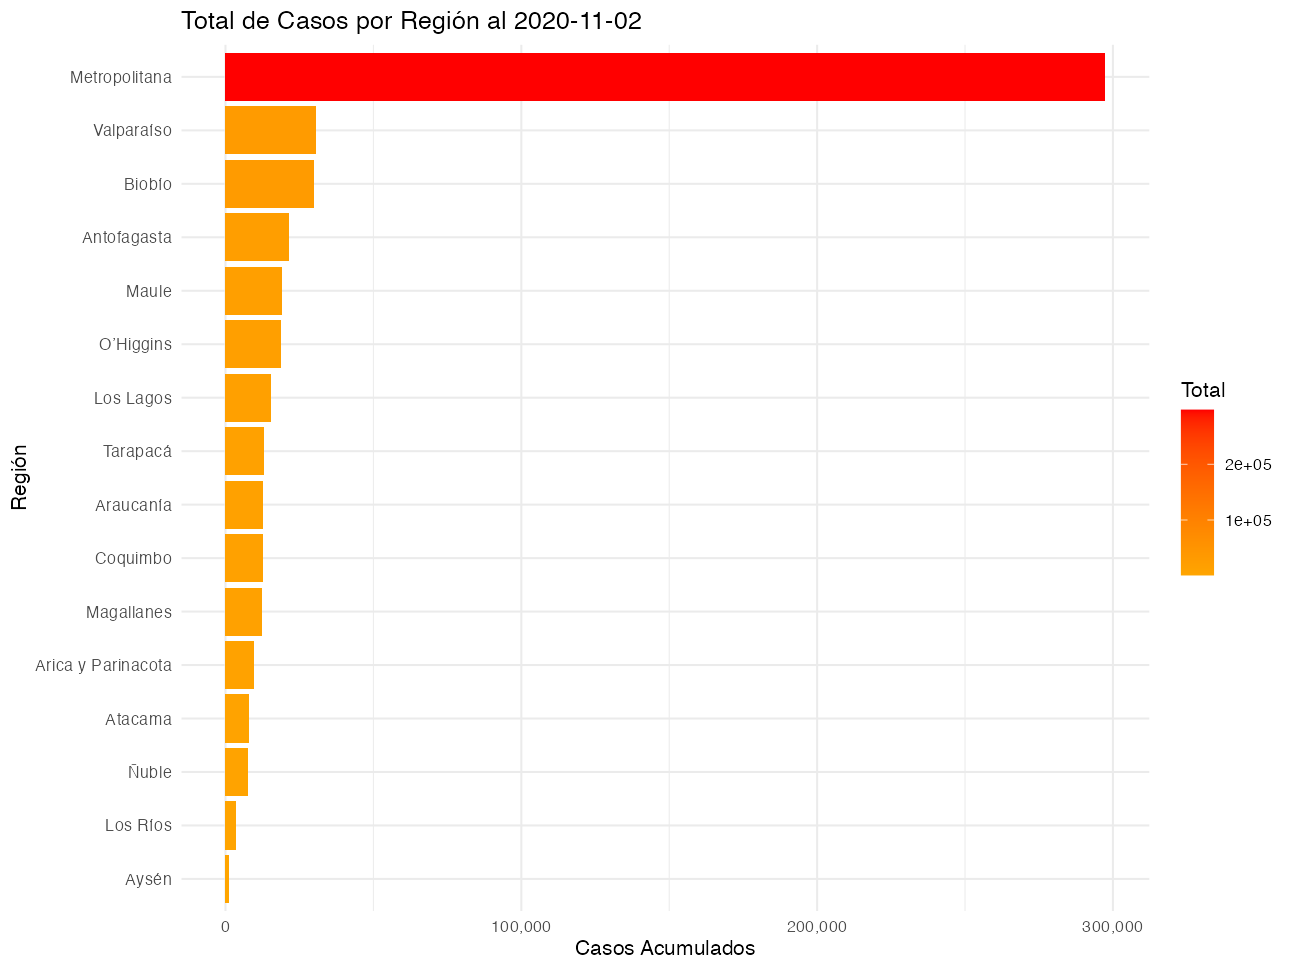

In [9]:
# 7. Visualización 3: Top Regiones con más casos (Última fecha registrada)
ultima_fecha <- max(df_regiones$Fecha)
top_regiones <- df_regiones %>%
  filter(Fecha == ultima_fecha) %>%
  arrange(desc(Total))

ggplot(top_regiones, aes(x = reorder(Region, Total), y = Total, fill = Total)) +
  geom_col() +
  coord_flip() +
  scale_y_continuous(labels = comma) +
  scale_fill_gradient(low = "orange", high = "red") +
  labs(title = paste("Total de Casos por Región al", ultima_fecha),
       x = "Región",
       y = "Casos Acumulados") +
  theme_minimal()

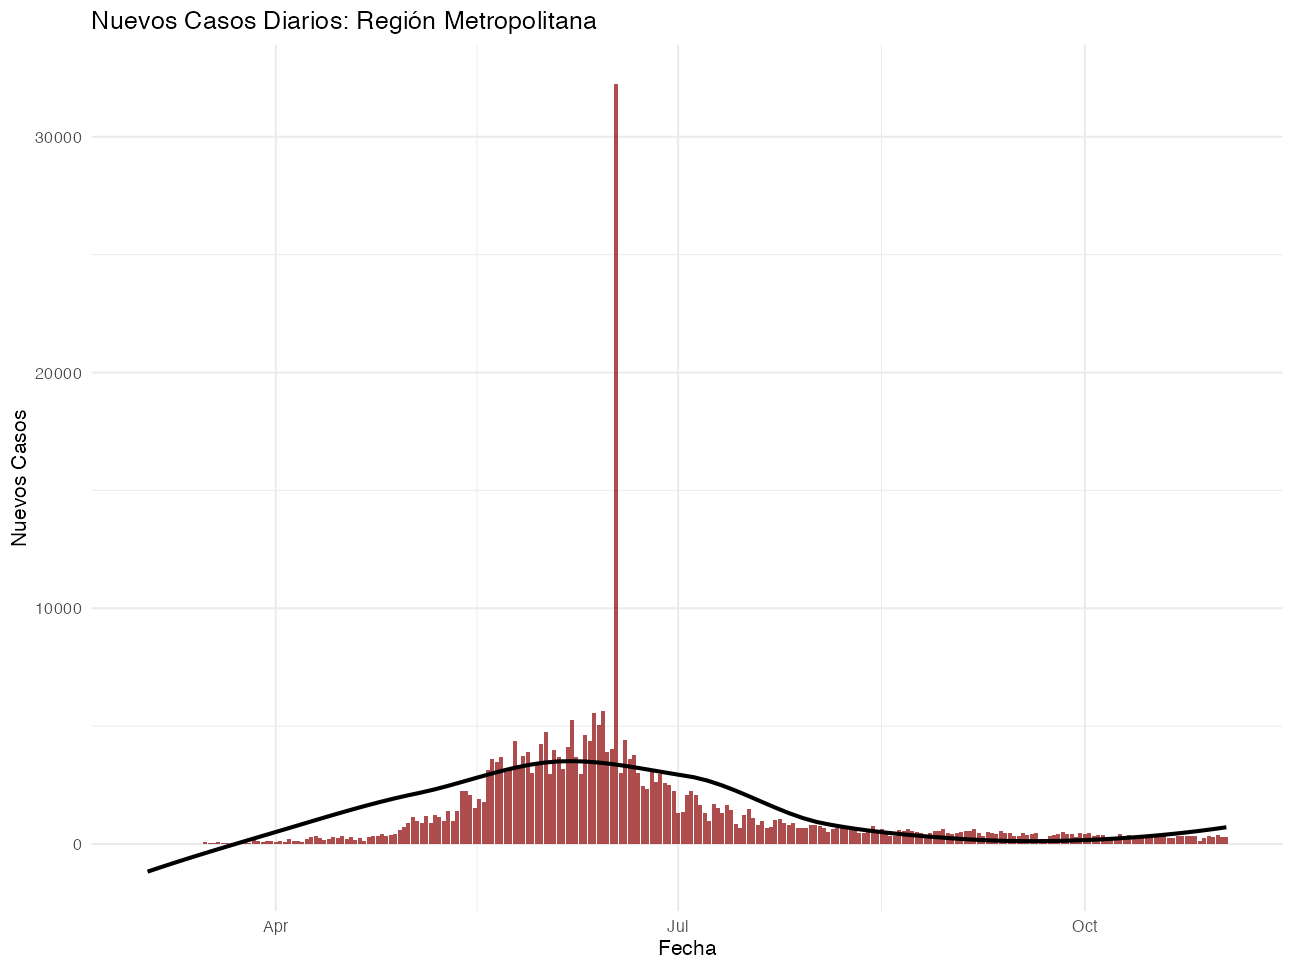

`geom_smooth()` using formula = 'y ~ x'

In [10]:
# 8. Análisis de nuevos casos diarios (Derivada del total acumulado)
# Calculamos la diferencia entre días para obtener casos nuevos
df_regiones_diario <- df_regiones %>%
  group_by(Region) %>%
  mutate(Casos_Diarios = Total - lag(Total, default = 0)) %>%
  filter(Casos_Diarios >= 0) # Eliminar posibles ajustes negativos de data

# Visualizar casos nuevos diarios en la Región Metropolitana (Ejemplo)
ggplot(df_regiones_diario %>% filter(Region == "Metropolitana"), 
       aes(x = Fecha, y = Casos_Diarios)) +
  geom_bar(stat = "identity", fill = "darkred", alpha = 0.7) +
  geom_smooth(method = "loess", color = "black", se = FALSE) +
  labs(title = "Nuevos Casos Diarios: Región Metropolitana",
       x = "Fecha",
       y = "Nuevos Casos") +
  theme_minimal()